ПАЙПЛАЙН ДЛЯ ОПЖ: ПРЕДСКАЗАНИЕ НА 2019 ГОД И СРАВНЕНИЕ
Загрузка данных ОПЖ...
Стандартизация названий регионов...
Уникальных регионов: 85
Период данных: 2014-2023
✓ Данные за 2019 год присутствуют

ОБУЧЕНИЕ МОДЕЛИ ОПЖ ДЛЯ ПРОГНОЗА НА 2019 ГОД
Обучение: 2014-2017, Валидация: 2018, Тестирование: 2019
Исходные данные: 2014-2023, 850 строк
Данные до обработки NaN: 850 строк
Данные после обработки NaN: 850 строк
Годы после обработки: 2014-2023
Используется 33 признаков
Обучающая выборка: (340, 33) (годы: 2014-2017)
Валидационная выборка: (85, 33) (год: 2018)
Тестовая выборка: (85, 33) (год: 2019)

Обучение модели...

РЕЗУЛЬТАТЫ ВАЛИДАЦИИ НА 2018 ГОДУ:
RMSE: 0.4770 лет
MAE: 0.3554 лет
R²: 0.9599
MAPE: 0.50%
Максимальная ошибка: 2.17 лет
Медианная ошибка: 0.32 лет
90% перцентиль ошибок: 0.60 лет

РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ НА 2019 ГОДУ:
RMSE: 0.3596 лет
MAE: 0.2514 лет
R²: 0.9753
MAPE: 0.35%
Максимальная ошибка: 1.48 лет
Медианная ошибка: 0.19 лет
90% перцентиль ошибок: 0.48 лет

Кросс-валидация

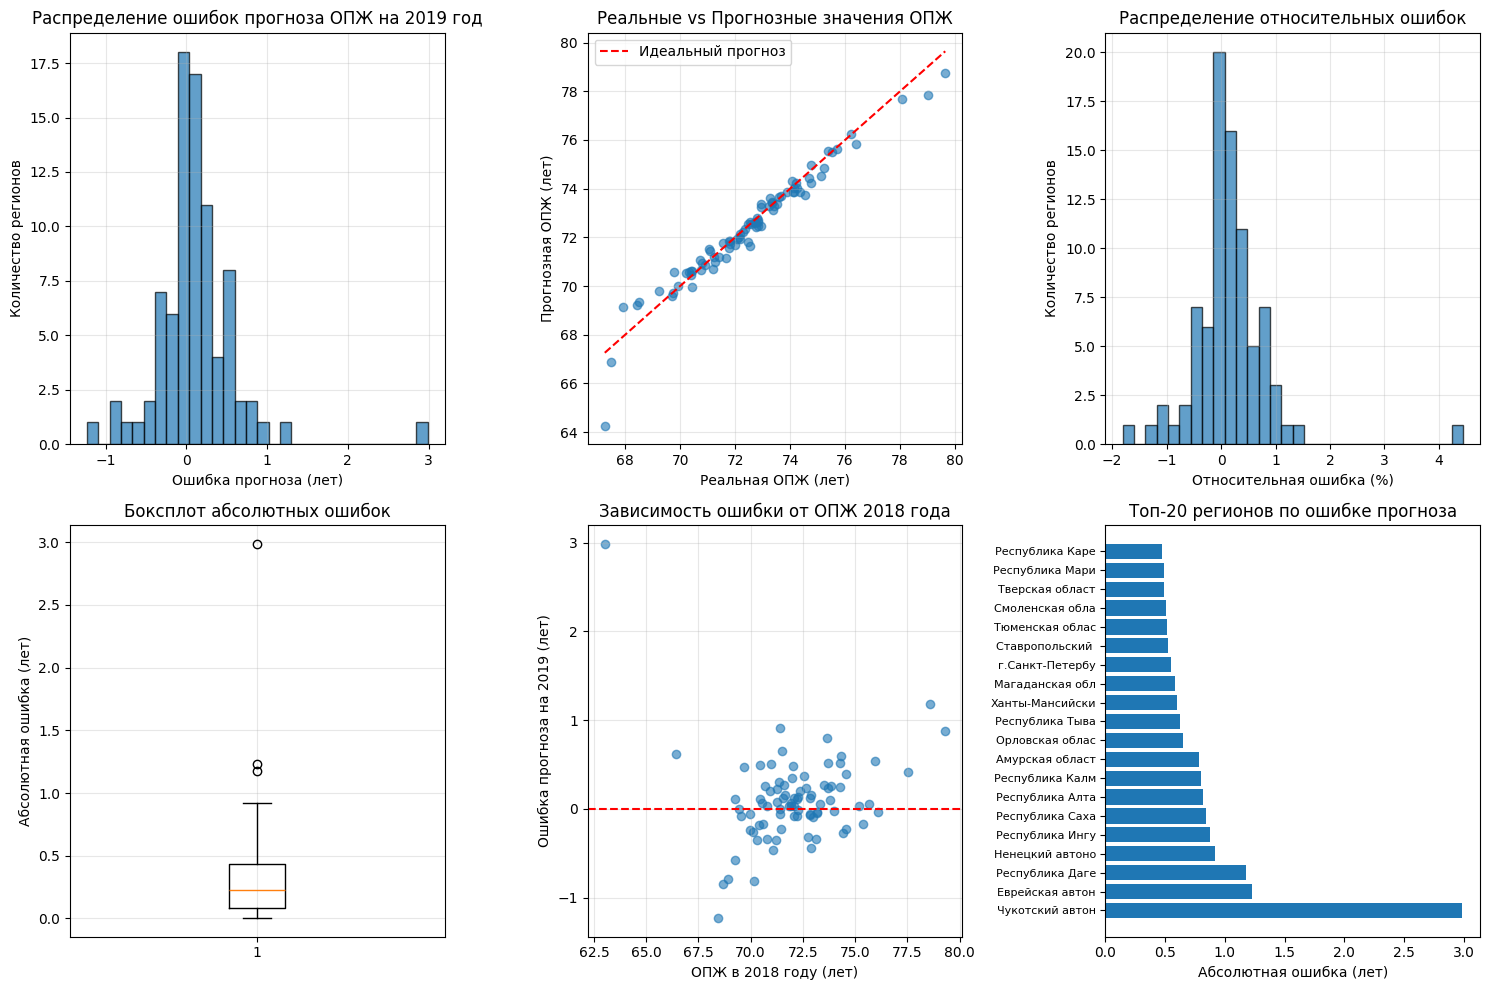

In [6]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import joblib
import os
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()

output_dir = current_dir 

def standardize_region_names(df):
    """Стандартизация названий регионов"""
    df_clean = df.copy()
    
    replacements = {
        'Ненецкий авт.округ': 'Ненецкий автономный округ',
        'Hенецкий авт.округ': 'Ненецкий автономный округ',
        '  Ненецкий автономный округ': 'Ненецкий автономный округ',
        
        'Ямало-Ненецкий авт.округ': 'Ямало-Ненецкий автономный округ',
        'Ямало-Hенецкий авт.округ': 'Ямало-Ненецкий автономный округ',
        '  Ямало-Ненецкий автономный округ': 'Ямало-Ненецкий автономный округ',
        
        'Ханты-Мансийский авт.округ-Югра': 'Ханты-Мансийский автономный округ - Югра',
        '  Ханты-Мансийский автономный округ - Югра': 'Ханты-Мансийский автономный округ - Югра',
        
        'Республика Татарстан(Татарстан)': 'Республика Татарстан',
        'Чувашская Республика(Чувашия)': 'Чувашская Республика',
        'Республика Северная Осетия- Алания': 'Республика Северная Осетия-Алания',
        
        'Oмская область': 'Омская область',
        'Hижегородская область': 'Нижегородская область',
        
        'г. Севастополь': 'г.Севастополь',
        'г.Москва': 'г.Москва',
        'г.Санкт-Петербург': 'г.Санкт-Петербург',
        
        'Чукотский авт.округ': 'Чукотский автономный округ',
        'Чукотский автономный округ': 'Чукотский автономный округ'
    }
    
    df_clean['Регион'] = df_clean['Регион'].replace(replacements)
    df_clean['Регион'] = df_clean['Регион'].str.strip()
    
    return df_clean

class OPJXGBoostForecasterAdvanced:
    def __init__(self, random_state=42):
        self.model = None
        self.scaler = StandardScaler()
        self.feature_names = []
        self.is_fitted = False
        self.last_known_data = None
        self.random_state = random_state
        self.first_year = None
        self.validation_results = None
        self.comparison_results = None
        
    def clean_numeric_columns(self, df):
        """
        Очистка числовых колонок
        """
        df = df.copy()
        
        numeric_columns = [col for col in df.columns if col not in ['Регион', 'Год', 'ОПЖ']]
        
        for col in numeric_columns:
            if df[col].dtype == 'object':
                df[col] = (df[col]
                          .astype(str)
                          .str.replace('\xa0', '')
                          .str.replace(' ', '')
                          .str.replace(',', '.')
                          .str.replace('−', '-')
                          .str.replace('–', '-')
                          )
                df[col] = pd.to_numeric(df[col], errors='coerce')
        
        if 'ОПЖ' in df.columns:
            df['ОПЖ'] = pd.to_numeric(df['ОПЖ'], errors='coerce')
        
        return df
        
    def prepare_features(self, df, is_training=True):
        """
        Подготовка признаков для ОПЖ с сохранением данных с 2014 года
        """
        df = df.copy().sort_values(['Регион', 'Год'])
        
        if self.first_year is None:
            self.first_year = df['Год'].min()
        
        print(f"Исходные данные: {df['Год'].min()}-{df['Год'].max()}, {len(df)} строк")
        
        # Создание лаговых признаков
        if is_training or df['Год'].min() < 2024:
            df['lag1_ОПЖ'] = df.groupby('Регион')['ОПЖ'].shift(1)
            df['lag2_ОПЖ'] = df.groupby('Регион')['ОПЖ'].shift(2)
            df['lag1_Число умерших'] = df.groupby('Регион')['Число умерших'].shift(1)
            df['lag1_Младенческая смертность коэф'] = df.groupby('Регион')['Младенческая смертность коэф'].shift(1)
            df['lag1_Общая численность инвалидов'] = df.groupby('Регион')['Общая численность инвалидов'].shift(1)
            
            df['ОПЖ_MA2'] = df.groupby('Регион')['ОПЖ'].transform(lambda x: x.rolling(2, min_periods=1).mean())
            df['ОПЖ_MA3'] = df.groupby('Регион')['ОПЖ'].transform(lambda x: x.rolling(3, min_periods=1).mean())
        
        df['year_trend'] = df['Год'] - self.first_year
        df['год_от_начала'] = df['Год'] - self.first_year
        
        # Создание производных медицинских и социальных показателей
        df['Врачей_на_10k'] = df['Численность врачей всех специальностей'] / df['Численность населения'] * 10000
        df['Умерших_на_1000'] = df['Число умерших'] / df['Численность населения'] * 1000
        df['Инвалидов_на_1000'] = df['Общая численность инвалидов'] / df['Численность населения'] * 1000
        df['Преступлений_на_1000'] = df['Кол-во преступлений'] / df['Численность населения'] * 1000
        df['Браков_на_1000'] = df['Браков'] / df['Численность населения'] * 1000
        df['Разводов_на_1000'] = df['Разводов'] / df['Численность населения'] * 1000
        
        df['Индекс_здравоохранения'] = (
            df['Врачей_на_10k'] + 
            df['Число больничных организаций на конец отчетного года'] + 
            df['Число санаторно-курортных организаций']
        ) / 3
        
        df['Социальный_индекс'] = (
            df['Средняя ЗП'] / df['Величина прожиточного минимума'] - 
            (df['Уровень бедности'] / 100)
        )
        
        df['изменение_населения'] = df.groupby('Регион')['Численность населения'].pct_change()
        df['изменение_ВРП'] = df.groupby('Регион')['Валовой региональный продукт на душу населения (ОКВЭД 2)'].pct_change()
        
        if is_training:
            print(f"Данные до обработки NaN: {len(df)} строк")
            
            numeric_cols = df.select_dtypes(include=[np.number]).columns
            for col in numeric_cols:
                if col not in ['Год']:
                    df[col] = df.groupby('Регион')[col].transform(
                        lambda x: x.fillna(x.median()) if not x.isnull().all() else x
                    )
            
            df = df.fillna(df.median(numeric_only=True))
            
            print(f"Данные после обработки NaN: {len(df)} строк")
            print(f"Годы после обработки: {df['Год'].min()}-{df['Год'].max()}")
        
        return df
    
    def train_validate_split(self, df, train_end_year=2017, validation_year=2018, test_year=2019):
        """
        Разделение на обучающую, валидационную и тестовую выборки
        """
        train_mask = df['Год'] <= train_end_year
        val_mask = df['Год'] == validation_year
        test_mask = df['Год'] == test_year
        
        return train_mask, val_mask, test_mask
    
    def fit_for_2019_prediction(self, df):
        """
        Обучение модели для предсказания 2019 года
        """
        print(f"\n{'='*70}")
        print(f"ОБУЧЕНИЕ МОДЕЛИ ОПЖ ДЛЯ ПРОГНОЗА НА 2019 ГОД")
        print(f"Обучение: 2014-2017, Валидация: 2018, Тестирование: 2019")
        print(f"{'='*70}")
        
        # Очистка и подготовка данных
        df_clean = self.clean_numeric_columns(df)
        df_processed = self.prepare_features(df_clean, is_training=True)
        
        # Разделение на обучающую, валидационную и тестовую выборки
        train_mask, val_mask, test_mask = self.train_validate_split(
            df_processed, train_end_year=2017, validation_year=2018, test_year=2019
        )
        
        # Определение признаков
        self.feature_names = [
            'Численность населения', 'Число умерших', 'Общая численность инвалидов',
            'Браков', 'Разводов', 'Младенческая смертность коэф', 
            'Численность врачей всех специальностей', 
            'Число больничных организаций на конец отчетного года', 
            'Число санаторно-курортных организаций',
            'Валовой региональный продукт на душу населения (ОКВЭД 2)',
            'Величина прожиточного минимума', 'Уровень бедности', 'Средняя ЗП',
            'Кол-во преступлений',
            'lag1_ОПЖ', 'lag2_ОПЖ', 'lag1_Число умерших', 
            'lag1_Младенческая смертность коэф', 'lag1_Общая численность инвалидов',
            'ОПЖ_MA2', 'ОПЖ_MA3', 'year_trend', 'год_от_начала',
            'Врачей_на_10k', 'Умерших_на_1000', 'Инвалидов_на_1000', 
            'Преступлений_на_1000', 'Браков_на_1000', 'Разводов_на_1000',
            'Индекс_здравоохранения', 'Социальный_индекс',
            'изменение_населения', 'изменение_ВРП'
        ]
        
        self.feature_names = [f for f in self.feature_names if f in df_processed.columns]
        print(f"Используется {len(self.feature_names)} признаков")
        
        # Подготовка данных
        X_train = df_processed[train_mask][self.feature_names]
        X_val = df_processed[val_mask][self.feature_names]
        X_test = df_processed[test_mask][self.feature_names]
        
        y_train = df_processed[train_mask]['ОПЖ']
        y_val = df_processed[val_mask]['ОПЖ']
        y_test = df_processed[test_mask]['ОПЖ']
        
        print(f"Обучающая выборка: {X_train.shape} (годы: 2014-2017)")
        print(f"Валидационная выборка: {X_val.shape} (год: 2018)")
        print(f"Тестовая выборка: {X_test.shape} (год: 2019)")
        
        # Масштабирование
        scale_features = [f for f in self.feature_names if not f.startswith(('lag', 'ОПЖ_MA', 'изменение_'))]
        X_train_scaled = X_train.copy()
        X_val_scaled = X_val.copy()
        X_test_scaled = X_test.copy()
        
        X_train_scaled[scale_features] = self.scaler.fit_transform(X_train[scale_features])
        X_val_scaled[scale_features] = self.scaler.transform(X_val[scale_features])
        X_test_scaled[scale_features] = self.scaler.transform(X_test[scale_features])
        
        # Обучение модели с улучшенными параметрами
        self.model = xgb.XGBRegressor(
            max_depth=6,
            learning_rate=0.03,
            n_estimators=400,
            random_state=self.random_state,
            n_jobs=-1,
            subsample=0.7,
            colsample_bytree=0.7,
            reg_alpha=0.1,
            reg_lambda=1.0
        )
        
        print("\nОбучение модели...")
        self.model.fit(X_train_scaled, y_train)
        self.is_fitted = True
        
        # Сохраняем данные за 2018 год для прогноза
        self.last_known_data = df_processed[df_processed['Год'] == 2018].copy()
        
        # Валидация на 2018 году
        y_val_pred = self.model.predict(X_val_scaled)
        
        # Расчет метрик валидации
        self.validation_results = {
            'y_true': y_val,
            'y_pred': y_val_pred,
            'year': 2018,
            'metrics': self._calculate_detailed_metrics(y_val, y_val_pred, "Валидация (2018)")
        }
        
        print(f"\n{'='*70}")
        print("РЕЗУЛЬТАТЫ ВАЛИДАЦИИ НА 2018 ГОДУ:")
        print(f"{'='*70}")
        self.print_metrics(self.validation_results['metrics'])
        
        # Тестирование на 2019 году
        y_test_pred = self.model.predict(X_test_scaled)
        
        # Расчет метрик тестирования
        self.test_results = {
            'y_true': y_test,
            'y_pred': y_test_pred,
            'year': 2019,
            'metrics': self._calculate_detailed_metrics(y_test, y_test_pred, "Тестирование (2019)")
        }
        
        print(f"\n{'='*70}")
        print("РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ НА 2019 ГОДУ:")
        print(f"{'='*70}")
        self.print_metrics(self.test_results['metrics'])
        
        # Кросс-валидация на обучающих данных
        self.cross_validation(X_train_scaled, y_train)
        
        # Сохранение всех данных для анализа
        self.results = {
            'X_train': X_train_scaled, 'X_val': X_val_scaled, 'X_test': X_test_scaled,
            'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
            'y_val_pred': y_val_pred, 'y_test_pred': y_test_pred,
            'df_processed': df_processed,
            'train_years': "2014-2017",
            'validation_year': 2018,
            'test_year': 2019
        }
        
        return self
    
    def _calculate_detailed_metrics(self, y_true, y_pred, context=""):
        """Расчет детализированных метрик"""
        mse = mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_true, y_pred)
        
        # Дополнительные метрики
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        max_error = np.max(np.abs(y_true - y_pred))
        median_error = np.median(np.abs(y_true - y_pred))
        
        # Процентили ошибок
        error_percentiles = np.percentile(np.abs(y_true - y_pred), [25, 50, 75, 90, 95])
        
        return {
            'MSE': mse, 'MAE': mae, 'RMSE': rmse, 'R2': r2,
            'MAPE': mape, 'MaxError': max_error, 'MedianError': median_error,
            'Error_25p': error_percentiles[0], 'Error_50p': error_percentiles[1],
            'Error_75p': error_percentiles[2], 'Error_90p': error_percentiles[3],
            'Error_95p': error_percentiles[4],
            'Context': context
        }
    
    def print_metrics(self, metrics):
        """Красивый вывод метрик"""
        print(f"RMSE: {metrics['RMSE']:.4f} лет")
        print(f"MAE: {metrics['MAE']:.4f} лет")
        print(f"R²: {metrics['R2']:.4f}")
        print(f"MAPE: {metrics['MAPE']:.2f}%")
        print(f"Максимальная ошибка: {metrics['MaxError']:.2f} лет")
        print(f"Медианная ошибка: {metrics['MedianError']:.2f} лет")
        print(f"90% перцентиль ошибок: {metrics['Error_90p']:.2f} лет")
    
    def cross_validation(self, X_train, y_train, cv=5):
        """
        Кросс-валидация для оценки устойчивости модели
        """
        print("\nКросс-валидация на обучающих данных:")
        
        temp_model = xgb.XGBRegressor(
            max_depth=6,
            learning_rate=0.03,
            n_estimators=200,
            random_state=self.random_state,
            n_jobs=-1,
            subsample=0.7,
            colsample_bytree=0.7
        )
        
        try:
            scores = cross_val_score(temp_model, X_train, y_train, 
                                   scoring='neg_mean_squared_error', cv=cv)
            rmse_scores = np.sqrt(-scores)
            print(f"Средний RMSE: {rmse_scores.mean():.4f} (+/- {rmse_scores.std() * 2:.4f})")
            print(f"Диапазон: {rmse_scores.min():.4f} - {rmse_scores.max():.4f}")
        except Exception as e:
            print(f"Ошибка при кросс-валидации: {e}")
    
    def predict_for_2019_and_compare(self, df):
        """
        Прогноз на 2019 год и подробное сравнение с реальными значениями
        """
        if not self.is_fitted:
            print("Сначала обучите модель!")
            return None
        
        print(f"\n{'='*70}")
        print(f"ПРОГНОЗ ОПЖ НА 2019 ГОД И СРАВНЕНИЕ С РЕАЛЬНЫМИ ДАННЫМИ")
        print(f"{'='*70}")
        
        # Получаем реальные значения за 2019 год
        real_2019 = df[df['Год'] == 2019][['Регион', 'ОПЖ']].copy()
        real_2019 = real_2019.rename(columns={'ОПЖ': 'ОПЖ_реальный'})
        
        # Получаем данные за 2018 год для прогноза
        data_2018 = self.last_known_data.copy()
        
        # Создаем прогноз на основе данных 2018 года
        all_predictions = []
        
        for _, last_row in data_2018.iterrows():
            future_row = last_row.copy()
            future_row['Год'] = 2019
            future_row['year_trend'] = 2019 - self.first_year
            future_row['год_от_начала'] = 2019 - self.first_year
            
            # Прогноз значений признаков с коэффициентами, характерными для 2018-2019
            growth_factors = {
                'Численность населения': 1.002,
                'Число умерших': 0.992,
                'Общая численность инвалидов': 1.0,
                'Младенческая смертность коэф': 0.97,
                'Валовой региональный продукт на душу населения (ОКВЭД 2)': 1.018,
                'Средняя ЗП': 1.045,
                'Численность врачей всех специальностей': 1.015,
                'Величина прожиточного минимума': 1.032,
                'Уровень бедности': 0.985,
                'Браков': 1.008,
                'Разводов': 1.003,
                'Кол-во преступлений': 0.995,
                'Число больничных организаций на конец отчетного года': 1.002,
                'Число санаторно-курортных организаций': 1.001
            }
            
            for col, factor in growth_factors.items():
                if col in future_row:
                    # Небольшая вариация для разных регионов
                    region_factor = 1.0 + np.random.normal(0, 0.01)
                    future_row[col] = last_row[col] * factor * region_factor
            
            # Лаги из 2018 года
            future_row['lag1_ОПЖ'] = last_row['ОПЖ']
            future_row['lag2_ОПЖ'] = last_row.get('lag1_ОПЖ', last_row['ОПЖ'])
            future_row['lag1_Число умерших'] = last_row['Число умерших']
            future_row['lag1_Младенческая смертность коэф'] = last_row['Младенческая смертность коэф']
            future_row['lag1_Общая численность инвалидов'] = last_row['Общая численность инвалидов']
            
            # Скользящие средние
            future_row['ОПЖ_MA2'] = (future_row['lag1_ОПЖ'] + last_row['ОПЖ']) / 2
            future_row['ОПЖ_MA3'] = (last_row.get('lag2_ОПЖ', last_row['ОПЖ']) + last_row['ОПЖ'] + future_row['lag1_ОПЖ']) / 3
            
            # Пересчет производных показателей
            future_row['Врачей_на_10k'] = future_row['Численность врачей всех специальностей'] / future_row['Численность населения'] * 10000
            future_row['Умерших_на_1000'] = future_row['Число умерших'] / future_row['Численность населения'] * 1000
            future_row['Инвалидов_на_1000'] = future_row['Общая численность инвалидов'] / future_row['Численность населения'] * 1000
            future_row['Преступлений_на_1000'] = future_row['Кол-во преступлений'] / future_row['Численность населения'] * 1000
            future_row['Браков_на_1000'] = future_row['Браков'] / future_row['Численность населения'] * 1000
            future_row['Разводов_на_1000'] = future_row['Разводов'] / future_row['Численность населения'] * 1000
            future_row['Индекс_здравоохранения'] = (
                future_row['Врачей_на_10k'] + 
                future_row['Число больничных организаций на конец отчетного года'] + 
                future_row['Число санаторно-курортных организаций']
            ) / 3
            future_row['Социальный_индекс'] = (
                future_row['Средняя ЗП'] / future_row['Величина прожиточного минимума'] - 
                (future_row['Уровень бедности'] / 100)
            )
            future_row['изменение_населения'] = (future_row['Численность населения'] - last_row['Численность населения']) / last_row['Численность населения']
            future_row['изменение_ВРП'] = (future_row['Валовой региональный продукт на душу населения (ОКВЭД 2)'] - last_row['Валовой региональный продукт на душу населения (ОКВЭД 2)']) / last_row['Валовой региональный продукт на душу населения (ОКВЭД 2)']
            
            all_predictions.append(future_row)
        
        # Создаем DataFrame для прогноза
        future_df = pd.DataFrame(all_predictions)
        X_future = future_df[self.feature_names]
        
        # Масштабирование
        scale_features = [f for f in self.feature_names if not f.startswith(('lag', 'ОПЖ_MA', 'изменение_'))]
        X_future_scaled = X_future.copy()
        X_future_scaled[scale_features] = self.scaler.transform(X_future[scale_features])
        
        # Прогноз ОПЖ на 2019 год
        predictions = self.model.predict(X_future_scaled)
        
        # Собираем результаты
        results = []
        for i, (_, last_row) in enumerate(data_2018.iterrows()):
            results.append({
                'Регион': last_row['Регион'],
                'Год': 2019,
                'ОПЖ_прогноз': predictions[i],
                'ОПЖ_2018': last_row['ОПЖ']
            })
        
        results_df = pd.DataFrame(results)
        
        # Объединяем с реальными значениями 2019 года
        comparison_df = pd.merge(results_df, real_2019, on='Регион', how='inner')
        
        # Рассчитываем ошибки
        comparison_df['Ошибка_абсолютная'] = comparison_df['ОПЖ_реальный'] - comparison_df['ОПЖ_прогноз']
        comparison_df['Ошибка_абсолютная_abs'] = np.abs(comparison_df['Ошибка_абсолютная'])
        comparison_df['Ошибка_относительная_%'] = (comparison_df['Ошибка_абсолютная'] / comparison_df['ОПЖ_реальный']) * 100
        
        # Рассчитываем метрики для прогноза
        self.calculate_prediction_metrics(comparison_df['ОПЖ_реальный'], comparison_df['ОПЖ_прогноз'])
        
        # Сохраняем результаты сравнения
        self.comparison_results = comparison_df.copy()
        
        print(f"\nПрогноз на 2019 год успешно создан")
        print(f"Сравнение выполнено для {len(comparison_df)} регионов")
        
        return comparison_df
    
    def calculate_prediction_metrics(self, y_true, y_pred):
        """
        Расчет метрик качества для прогноза
        """
        mse = mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_true, y_pred)
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        
        print(f"\nМЕТРИКИ КАЧЕСТВА ПРОГНОЗА НА 2019 ГОД:")
        print(f"RMSE: {rmse:.4f} лет")
        print(f"MAE: {mae:.4f} лет")
        print(f"R²: {r2:.4f}")
        print(f"MAPE: {mape:.2f}%")
        print(f"Средняя реальная ОПЖ: {y_true.mean():.2f} лет")
        print(f"Средняя прогнозная ОПЖ: {y_pred.mean():.2f} лет")
        print(f"Разница: {y_true.mean() - y_pred.mean():.4f} лет")
        
        # Сохраняем метрики прогноза
        self.prediction_metrics = {
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2,
            'MAPE': mape,
            'Mean_Actual': y_true.mean(),
            'Mean_Predicted': y_pred.mean()
        }
    
    def analyze_comparison_results(self, comparison_df):
        """
        Детальный анализ результатов сравнения
        """
        print(f"\n{'='*70}")
        print("ДЕТАЛЬНЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ СРАВНЕНИЯ")
        print(f"{'='*70}")
        
        print(f"\nОБЩАЯ СТАТИСТИКА:")
        print(f"Всего регионов: {len(comparison_df)}")
        print(f"Средняя реальная ОПЖ: {comparison_df['ОПЖ_реальный'].mean():.2f} лет")
        print(f"Средняя прогнозная ОПЖ: {comparison_df['ОПЖ_прогноз'].mean():.2f} лет")
        print(f"Средняя абсолютная ошибка: {comparison_df['Ошибка_абсолютная_abs'].mean():.3f} лет")
        print(f"Медианная абсолютная ошибка: {comparison_df['Ошибка_абсолютная_abs'].median():.3f} лет")
        print(f"Максимальная ошибка: {comparison_df['Ошибка_абсолютная_abs'].max():.3f} лет")
        print(f"Минимальная ошибка: {comparison_df['Ошибка_абсолютная_abs'].min():.3f} лет")
        
        # Статистика по ошибкам
        print(f"\nСТАТИСТИКА ПО ОШИБКАМ:")
        error_positive = (comparison_df['Ошибка_абсолютная'] > 0).sum()
        error_negative = (comparison_df['Ошибка_абсолютная'] < 0).sum()
        print(f"Прогноз занижен (реальный > прогноз): {error_positive} регионов")
        print(f"Прогноз завышен (реальный < прогноз): {error_negative} регионов")
        
        # Топ регионов по точности прогноза
        print(f"\nТОП-10 РЕГИОНОВ С НАИБОЛЕЕ ТОЧНЫМ ПРОГНОЗОМ:")
        top_accurate = comparison_df.nsmallest(10, 'Ошибка_абсолютная_abs')
        for i, row in top_accurate.iterrows():
            print(f"  {row['Регион'][:30]:<30} | Ошибка: {row['Ошибка_абсолютная_abs']:.3f} лет | "
                  f"Реальный: {row['ОПЖ_реальный']:.2f} | Прогноз: {row['ОПЖ_прогноз']:.2f}")
        
        # Топ регионов с наибольшей ошибкой
        print(f"\nТОП-10 РЕГИОНОВ С НАИБОЛЬШЕЙ ОШИБКОЙ:")
        top_error = comparison_df.nlargest(10, 'Ошибка_абсолютная_abs')
        for i, row in top_error.iterrows():
            print(f"  {row['Регион'][:30]:<30} | Ошибка: {row['Ошибка_абсолютная_abs']:.3f} лет | "
                  f"Реальный: {row['ОПЖ_реальный']:.2f} | Прогноз: {row['ОПЖ_прогноз']:.2f}")
        
        # Анализ распределения ошибок
        error_quartiles = np.percentile(comparison_df['Ошибка_абсолютная_abs'], [25, 50, 75, 90, 95])
        print(f"\nКВАРТИЛИ АБСОЛЮТНОЙ ОШИБКИ:")
        print(f"  25-й перцентиль: {error_quartiles[0]:.3f} лет")
        print(f"  50-й перцентиль (медиана): {error_quartiles[1]:.3f} лет")
        print(f"  75-й перцентиль: {error_quartiles[2]:.3f} лет")
        print(f"  90-й перцентиль: {error_quartiles[3]:.3f} лет")
        print(f"  95-й перцентиль: {error_quartiles[4]:.3f} лет")
        
        # Сохраняем графики анализа
        self.create_comparison_plots(comparison_df)
    
    def create_comparison_plots(self, comparison_df):
        """
        Создание графиков для анализа сравнения
        """
        plt.figure(figsize=(15, 10))
        
        # График 1: Распределение ошибок
        plt.subplot(2, 3, 1)
        plt.hist(comparison_df['Ошибка_абсолютная'], bins=30, edgecolor='black', alpha=0.7)
        plt.xlabel('Ошибка прогноза (лет)')
        plt.ylabel('Количество регионов')
        plt.title('Распределение ошибок прогноза ОПЖ на 2019 год')
        plt.grid(True, alpha=0.3)
        
        # График 2: Реальные vs прогнозные значения
        plt.subplot(2, 3, 2)
        plt.scatter(comparison_df['ОПЖ_реальный'], comparison_df['ОПЖ_прогноз'], alpha=0.6)
        plt.plot([comparison_df['ОПЖ_реальный'].min(), comparison_df['ОПЖ_реальный'].max()],
                [comparison_df['ОПЖ_реальный'].min(), comparison_df['ОПЖ_реальный'].max()], 
                'r--', label='Идеальный прогноз')
        plt.xlabel('Реальная ОПЖ (лет)')
        plt.ylabel('Прогнозная ОПЖ (лет)')
        plt.title('Реальные vs Прогнозные значения ОПЖ')
        plt.grid(True, alpha=0.3)
        plt.legend()
        
        # График 3: Распределение относительных ошибок
        plt.subplot(2, 3, 3)
        plt.hist(comparison_df['Ошибка_относительная_%'], bins=30, edgecolor='black', alpha=0.7)
        plt.xlabel('Относительная ошибка (%)')
        plt.ylabel('Количество регионов')
        plt.title('Распределение относительных ошибок')
        plt.grid(True, alpha=0.3)
        
        # График 4: Боксплот ошибок
        plt.subplot(2, 3, 4)
        plt.boxplot(comparison_df['Ошибка_абсолютная_abs'])
        plt.ylabel('Абсолютная ошибка (лет)')
        plt.title('Боксплот абсолютных ошибок')
        plt.grid(True, alpha=0.3)
        
        # График 5: Сравнение с 2018 годом
        plt.subplot(2, 3, 5)
        plt.scatter(comparison_df['ОПЖ_2018'], comparison_df['Ошибка_абсолютная'], alpha=0.6)
        plt.xlabel('ОПЖ в 2018 году (лет)')
        plt.ylabel('Ошибка прогноза на 2019 (лет)')
        plt.title('Зависимость ошибки от ОПЖ 2018 года')
        plt.grid(True, alpha=0.3)
        plt.axhline(y=0, color='r', linestyle='--')
        
        # График 6: Топ-20 регионов по ошибкам
        plt.subplot(2, 3, 6)
        top_regions = comparison_df.nlargest(20, 'Ошибка_абсолютная_abs')
        plt.barh(range(len(top_regions)), top_regions['Ошибка_абсолютная_abs'])
        plt.yticks(range(len(top_regions)), top_regions['Регион'].str[:15], fontsize=8)
        plt.xlabel('Абсолютная ошибка (лет)')
        plt.title('Топ-20 регионов по ошибке прогноза')
        plt.tight_layout()
        
        # Сохранение графика
        plot_filepath = os.path.join(output_dir, 'opj_comparison_analysis_2019.png')
        plt.savefig(plot_filepath, dpi=300, bbox_inches='tight')
        print(f"\n✓ График анализа сравнения сохранен как '{plot_filepath}'")
    
    def prepare_final_comparison_output(self, comparison_df):
        """
        Подготовка финального файла с прогнозами и сравнением
        """
        # Создаем DataFrame с прогнозами и реальными значениями
        final_output = pd.DataFrame({
            'Регион': comparison_df['Регион'],
            'Год': comparison_df['Год'],
            'ОПЖ_прогноз': comparison_df['ОПЖ_прогноз'],
            'ОПЖ_реальный': comparison_df['ОПЖ_реальный'],
            'ОПЖ_2018': comparison_df['ОПЖ_2018'],
            'Ошибка_абсолютная': comparison_df['Ошибка_абсолютная'],
            'Ошибка_абсолютная_abs': comparison_df['Ошибка_абсолютная_abs'],
            'Ошибка_относительная_%': comparison_df['Ошибка_относительная_%']
        })
        
        # Добавляем ранги по точности
        final_output['Ранг_точности'] = final_output['Ошибка_абсолютная_abs'].rank(method='dense').astype(int)
        
        return final_output
    
    def save_model(self, filepath=None):
        """Сохранение модели"""
        if not self.is_fitted:
            print("Модель не обучена!")
            return False
        
        if filepath is None:
            filepath = os.path.join(output_dir, 'opj_xgboost_2019_model.pkl')
        
        model_data = {
            'model': self.model,
            'scaler': self.scaler,
            'feature_names': self.feature_names,
            'first_year': self.first_year,
            'last_known_data': self.last_known_data,
            'validation_results': self.validation_results,
            'test_results': self.test_results,
            'comparison_results': self.comparison_results,
            'random_state': self.random_state,
            'prediction_metrics': getattr(self, 'prediction_metrics', None)
        }
        
        joblib.dump(model_data, filepath)
        print(f"Модель ОПЖ для 2019 года сохранена в {filepath}")
        return True
    
    def load_model(self, filepath=None):
        """Загрузка модели"""
        if filepath is None:
            filepath = os.path.join(output_dir, 'opj_xgboost_2019_model.pkl')
            
        if not os.path.exists(filepath):
            print(f"Файл модели {filepath} не найден!")
            return False
        
        model_data = joblib.load(filepath)
        self.model = model_data['model']
        self.scaler = model_data['scaler']
        self.feature_names = model_data['feature_names']
        self.first_year = model_data['first_year']
        self.last_known_data = model_data['last_known_data']
        self.validation_results = model_data['validation_results']
        self.test_results = model_data['test_results']
        self.comparison_results = model_data['comparison_results']
        self.random_state = model_data.get('random_state', 42)
        self.prediction_metrics = model_data.get('prediction_metrics', None)
        self.is_fitted = True
        
        print(f"Модель ОПЖ для 2019 года загружена из {filepath}")
        return True

# Главная функция для ОПЖ с предсказанием на 2019 год
def run_opj_2019_comparison():
    """
    Запуск пайплайна для ОПЖ с предсказанием на 2019 год и сравнением
    """
    print("="*80)
    print("ПАЙПЛАЙН ДЛЯ ОПЖ: ПРЕДСКАЗАНИЕ НА 2019 ГОД И СРАВНЕНИЕ")
    print("="*80)
    
    # Создаем директорию для результатов
    os.makedirs(output_dir, exist_ok=True)
    
    # Загрузка данных
    print("Загрузка данных ОПЖ...")
    try:
        df_opj = pd.read_excel('../../Финальный вариант/общая_ОПЖ (2).xlsx')
    except FileNotFoundError:
        print("ОШИБКА: Файл 'общая_ОПЖ (2).xlsx' не найден!")
        print("Убедитесь, что файл находится в папке 'Финальный вариант'")
        return None
    
    # Стандартизация регионов
    print("Стандартизация названий регионов...")
    df_opj = standardize_region_names(df_opj)
    print(f"Уникальных регионов: {df_opj['Регион'].nunique()}")
    print(f"Период данных: {df_opj['Год'].min()}-{df_opj['Год'].max()}")
    
    # Проверка наличия данных за 2019 год
    if 2019 not in df_opj['Год'].unique():
        print("ВНИМАНИЕ: В данных нет 2019 года!")
        print("Используем последний доступный год для тестирования...")
        last_year = max(df_opj['Год'].unique())
        target_year = last_year
        print(f"Будем прогнозировать для {target_year} года")
    else:
        target_year = 2019
        print(f"✓ Данные за 2019 год присутствуют")
    
    # Создание и обучение модели
    opj_forecaster = OPJXGBoostForecasterAdvanced()
    
    # Обучение модели для прогноза на 2019 год
    opj_forecaster.fit_for_2019_prediction(df_opj)
    
    # Прогноз на 2019 год и сравнение
    comparison_results = opj_forecaster.predict_for_2019_and_compare(df_opj)
    
    if comparison_results is not None:
        # Детальный анализ результатов
        opj_forecaster.analyze_comparison_results(comparison_results)
        
        # Подготовка финального вывода
        final_output = opj_forecaster.prepare_final_comparison_output(comparison_results)
        
        # Сохранение результатов
        comparison_filepath = os.path.join(output_dir, 'opj_predictions_comparison_2019.xlsx')
        final_output.to_excel(comparison_filepath, index=False)
        print(f"\n✓ Финальный файл с прогнозами и сравнением сохранен как '{comparison_filepath}'")
        
        # Сохранение сводной статистики
        summary_filepath = os.path.join(output_dir, 'opj_comparison_summary_2019.csv')
        
        summary_stats = {
            'Метрика': ['RMSE', 'MAE', 'R2', 'MAPE (%)', 'Средний реальный ОПЖ', 
                       'Средний прогнозный ОПЖ', 'Разница средних'],
            'Значение': [
                opj_forecaster.prediction_metrics['RMSE'],
                opj_forecaster.prediction_metrics['MAE'],
                opj_forecaster.prediction_metrics['R2'],
                opj_forecaster.prediction_metrics['MAPE'],
                opj_forecaster.prediction_metrics['Mean_Actual'],
                opj_forecaster.prediction_metrics['Mean_Predicted'],
                opj_forecaster.prediction_metrics['Mean_Actual'] - opj_forecaster.prediction_metrics['Mean_Predicted']
            ]
        }
        
        summary_df = pd.DataFrame(summary_stats)
        summary_df.to_csv(summary_filepath, index=False)
        print(f"✓ Сводная статистика сохранена как '{summary_filepath}'")
        
        # Сохранение модели
        opj_forecaster.save_model()
        
        print(f"\n{'='*70}")
        print("ПАЙПЛАЙН ДЛЯ ОПЖ УСПЕШНО ЗАВЕРШЕН!")
        print(f"Результаты сохранены в папке: {output_dir}")
        print(f"{'='*70}")
        
        # Вывод примеров
        print("\nПРИМЕРЫ РЕЗУЛЬТАТОВ:")
        print("-" * 50)
        
        # Примеры лучших прогнозов
        best_predictions = final_output.nsmallest(5, 'Ошибка_абсолютная_abs')
        print("\nЛучшие прогнозы:")
        for _, row in best_predictions.iterrows():
            print(f"  {row['Регион'][:25]:<25} | Ошибка: {row['Ошибка_абсолютная_abs']:.3f} лет")
        
        # Примеры худших прогнозов
        worst_predictions = final_output.nlargest(5, 'Ошибка_абсолютная_abs')
        print("\nХудшие прогнозы:")
        for _, row in worst_predictions.iterrows():
            print(f"  {row['Регион'][:25]:<25} | Ошибка: {row['Ошибка_абсолютная_abs']:.3f} лет")
        
        return comparison_filepath
    
    return None

if __name__ == "__main__":
    # Запускаем пайплайн для ОПЖ с предсказанием на 2019 год
    comparison_file = run_opj_2019_comparison()
    
    if comparison_file:
        print(f"\nПайплайн выполнен успешно!")
        print(f"Файл с результатами сравнения создан: {comparison_file}")
    else:
        print("\nПайплайн завершился с ошибкой")